In [2]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np

# =============================
# 1. LOAD AND PREPROCESS DATA
# =============================

file_name = 'training_session.csv'
df = pd.read_csv(file_name, header=None)

# Assign 8 column names
df.columns = [
    'first_name', 'last_name', 'gender', 'col_d',
    'category', 'assessment', 'score', 'timestamp'
]

# Convert types
df['score'] = pd.to_numeric(df['score'], errors='coerce')
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Drop rows with missing score
df = df.dropna(subset=['score']).copy()

# Clean text columns
text_cols = ['first_name', 'last_name', 'gender', 'col_d', 'category', 'assessment']
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

# Combine category and assessment
df['category_assessment'] = df['category'] + ' ' + df['assessment']

# Map age groups
age_map = {
    'A': 1, 'B': 1,
    'C': 2, 'D': 2,
    'E': 3, 'F': 3
}
df['age_group'] = df['col_d'].map(age_map)

# Standardize gender
df['gender_clean'] = df['gender'].str.upper().str[0]

# Keep only M / F if possible
df['gender_clean'] = df['gender_clean'].replace({
    'M': 'M',
    'F': 'F'
})

# Create cohort column
df['cohort'] = df['age_group'].astype('Int64').astype(str) + "_" + df['gender_clean']

# Drop rows with invalid cohort pieces
df = df[
    df['age_group'].notna() &
    df['gender_clean'].isin(['M', 'F'])
].copy()

# Drop unwanted category_assessment values
drop_category_assessments = [
    'Broad Jump 5-10-5 Shuttles',
    'Broad Jump Horizontal',
    'Circuit Training Maestro',
    'Circuit Training Vision',
    'ICON Q Pass Find 2',
    'Tech Touch One Touch Pass Pass 10 Air',
    'Tech Touch One Touch Pass Pass 10 Ground'
]

df = df[~df['category_assessment'].isin(drop_category_assessments)].copy()

# Optional: remove impossible or zero/negative scores if needed
# df = df[df['score'] > 0].copy()

print("Preprocessed shape:", df.shape)
df.head()

Preprocessed shape: (13514, 12)


,first_name,last_name,gender,col_d,category,assessment,score,timestamp,category_assessment,age_group,gender_clean,cohort
0,Alex,Lee,male,F,Circuit Training,Knockout,35.0,2022-10-03 23:02:33,Circuit Training Knockout,3,M,3_M
1,Carter,Maris,male,E,Tech Touch Ground & Tech Touch Air,Receive 10 Air,10.0,2022-10-04 16:57:01,Tech Touch Ground & Tech Touch Air Receive 10 Air,3,M,3_M
2,Carter,Maris,male,E,Circuit Training,Pass Find 1,19.0,2022-10-04 17:13:35,Circuit Training Pass Find 1,3,M,3_M
3,Carter,Maris,male,E,Circuit Training,Knockout,7.0,2022-10-04 17:15:42,Circuit Training Knockout,3,M,3_M
4,Carter,Maris,male,E,Circuit Training,Knockout-Obstacle,10.1,2022-10-04 17:18:54,Circuit Training Knockout-Obstacle,3,M,3_M


In [4]:
# ============================================
# 2. DEFINE SCORE DIRECTION FOR EACH ASSESSMENT
# ============================================

# IMPORTANT:
# Set whether HIGHER score is better for each assessment.
# If an assessment is time-based, often LOWER is better.
# Update this dictionary based on your domain understanding.

higher_is_better_map = {
    # Examples
    'Circuit Training Knockout': False,
    'Circuit Training Knockout-Obstacle': False,
    'Circuit Training Pass Find 1': True,
    'Tech Touch Ground & Tech Touch Air Receive 10 Air': True,
    'Tech Touch Ground & Tech Touch Air Receive 10 Ground': True,
    'Vertical Jump Vertical': True,

    # Add more as needed...
}

# Default behavior if not listed
DEFAULT_HIGHER_IS_BETTER = True

df['higher_is_better'] = (
    df['category_assessment']
    .map(higher_is_better_map)
    .fillna(DEFAULT_HIGHER_IS_BETTER)
)


# ==========================================================
# 3. CREATE SCORING INPUT USING MOST RECENT PLAYER SCORE ONLY
# ==========================================================

# For APS and RPS, use only the most recent score for each player-assessment.
# This keeps your original df intact and creates a separate scoring_df.

player_cols = ['first_name', 'last_name', 'gender_clean', 'age_group']

scoring_df = (
    df.sort_values('timestamp')
      .drop_duplicates(subset=player_cols + ['category_assessment'], keep='last')
      .copy()
)

print("Scoring input shape (most recent attempt only):", scoring_df.shape)


# ============================================
# 4. BUILD APS BENCHMARK TABLE BY COHORT + SKILL
# ============================================

# We will use quantile-based benchmarks.
# These can later be shown in a benchmark table or dashboard.

benchmark_quantiles = [0.10, 0.25, 0.50, 0.75, 0.90]

benchmark_table = (
    scoring_df.groupby(['category_assessment', 'cohort'])['score']
              .quantile(benchmark_quantiles)
              .unstack()
              .reset_index()
)

benchmark_table.columns = [
    'category_assessment', 'cohort',
    'q10', 'q25', 'q50', 'q75', 'q90'
]

# Add sample size for transparency / filtering
sample_sizes = (
    scoring_df.groupby(['category_assessment', 'cohort'])
              .size()
              .reset_index(name='n_cohort_assessment')
)

benchmark_table = benchmark_table.merge(
    sample_sizes,
    on=['category_assessment', 'cohort'],
    how='left'
)

print("\nBenchmark table preview:")
print(benchmark_table.head())


# ============================================
# 5. APS FUNCTION
# ============================================

# APS = Absolute Performance Score
# Here we convert raw score into a 0-100 score using benchmark interpolation.
#
# Piecewise benchmark anchors:
# q10 -> 10
# q25 -> 25
# q50 -> 50
# q75 -> 75
# q90 -> 90
#
# Below q10 or above q90 gets extrapolated but clipped to [0, 100].

def interpolate_score(x, x0, x1, y0, y1):
    if pd.isna(x0) or pd.isna(x1) or x1 == x0:
        return np.nan
    return y0 + (x - x0) * (y1 - y0) / (x1 - x0)

def aps_from_benchmarks(score, q10, q25, q50, q75, q90, higher_is_better=True):
    """
    Convert raw score to APS on a 0-100 scale using cohort-specific benchmarks.
    """
    if any(pd.isna(v) for v in [score, q10, q25, q50, q75, q90]):
        return np.nan

    # If lower is better, flip orientation so bigger transformed value is better
    if not higher_is_better:
        score = -score
        q10, q25, q50, q75, q90 = sorted([-q90, -q75, -q50, -q25, -q10])

    if score <= q10:
        aps = interpolate_score(score, q10 - (q25 - q10), q10, 0, 10)
    elif score <= q25:
        aps = interpolate_score(score, q10, q25, 10, 25)
    elif score <= q50:
        aps = interpolate_score(score, q25, q50, 25, 50)
    elif score <= q75:
        aps = interpolate_score(score, q50, q75, 50, 75)
    elif score <= q90:
        aps = interpolate_score(score, q75, q90, 75, 90)
    else:
        aps = interpolate_score(score, q90, q90 + (q90 - q75), 90, 100)

    return float(np.clip(aps, 0, 100))


# Merge benchmarks back to row-level scoring data
scoring_df = scoring_df.merge(
    benchmark_table,
    on=['category_assessment', 'cohort'],
    how='left'
)

# Calculate APS
scoring_df['APS'] = scoring_df.apply(
    lambda row: aps_from_benchmarks(
        score=row['score'],
        q10=row['q10'],
        q25=row['q25'],
        q50=row['q50'],
        q75=row['q75'],
        q90=row['q90'],
        higher_is_better=row['higher_is_better']
    ),
    axis=1
)


# ============================================
# 6. RPS WITH LAMBDA SMOOTHING
# ============================================

# Raw RPS idea:
# percentile within (category_assessment, cohort)
#
# Lambda smoothing idea:
# shrink raw percentile toward 50 when cohort sample is small
#
# Formula:
# smoothed_rps = (n / (n + lambda)) * raw_percentile + (lambda / (n + lambda)) * 50
#
# Interpretation:
# - larger lambda = more conservative
# - smaller lambda = more data-driven
# - good starting values: 10, 20, 30

LAMBDA = 20

def compute_raw_percentile(group):
    """
    Computes percentile rank within each category_assessment x cohort group.
    Handles higher-is-better vs lower-is-better.
    """
    group = group.copy()

    higher_is_better = group['higher_is_better'].iloc[0]

    if higher_is_better:
        group['rank_order_value'] = group['score']
    else:
        group['rank_order_value'] = -group['score']

    # Percentile rank from 0 to 100
    group['raw_rps'] = group['rank_order_value'].rank(method='average', pct=True) * 100

    # Cohort size
    group['n_group'] = len(group)

    # Lambda smoothed percentile
    group['RPS'] = (
        (group['n_group'] / (group['n_group'] + LAMBDA)) * group['raw_rps']
        + (LAMBDA / (group['n_group'] + LAMBDA)) * 50
    )

    return group

scoring_df = (
    scoring_df.groupby(['category_assessment', 'cohort'], group_keys=False)
              .apply(compute_raw_percentile)
              .copy()
)


# ============================================
# 6B. APS PERFORMANCE BANDS
# ============================================

# Band order:
# Elite
# Strong
# Approaching
# Developing
# Foundation

def assign_aps_band(score, q25, q50, q75, q90, higher_is_better=True):
    if any(pd.isna(v) for v in [score, q25, q50, q75, q90]):
        return None

    if not higher_is_better:
        score = -score
        q25, q50, q75, q90 = sorted([-q90, -q75, -q50, -q25])

    if score >= q90:
        return "Elite"
    elif score >= q75:
        return "Strong"
    elif score >= q50:
        return "Approaching"
    elif score >= q25:
        return "Developing"
    else:
        return "Foundation"

scoring_df['APS_band'] = scoring_df.apply(
    lambda row: assign_aps_band(
        score=row['score'],
        q25=row['q25'],
        q50=row['q50'],
        q75=row['q75'],
        q90=row['q90'],
        higher_is_better=row['higher_is_better']
    ),
    axis=1
)


# ============================================
# 7. OPTIONAL: CREATE SUMMARY TABLES
# ============================================

# Benchmark summary table
aps_benchmark_summary = (
    benchmark_table
    .sort_values(['category_assessment', 'cohort'])
    .reset_index(drop=True)
)

# Score summary table
score_output = scoring_df[[
    'first_name', 'last_name', 'gender', 'col_d',
    'age_group', 'gender_clean', 'cohort',
    'category', 'assessment', 'category_assessment',
    'score', 'timestamp',
    'n_cohort_assessment',
    'APS', 'APS_band', 'raw_rps', 'RPS'
]].sort_values(['category_assessment', 'cohort', 'timestamp']).reset_index(drop=True)

print("\nFinal row-level output preview:")
print(score_output.head())

print("\nAPS benchmark summary preview:")
print(aps_benchmark_summary.head())


# ============================================
# 8. OPTIONAL: EXPORT RESULTS
# ============================================

# score_output.to_csv('scored_training_sessions.csv', index=False)
# aps_benchmark_summary.to_csv('aps_benchmark_table.csv', index=False)

score_output.head(20)

/tmp/ipykernel_8898/731802706.py:28: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(DEFAULT_HIGHER_IS_BETTER)


Scoring input shape (most recent attempt only): (7339, 13)

Benchmark table preview:
         category_assessment cohort    q10    q25    q50    q75     q90  \
0  Circuit Training Knockout    1_F  8.600  9.885  11.00  13.90  21.000   
1  Circuit Training Knockout    1_M  7.080  8.700  10.60  15.00  19.720   
2  Circuit Training Knockout    2_F  6.720  7.200   8.30  10.00  14.748   
3  Circuit Training Knockout    2_M  6.179  7.000   8.90  10.15  13.280   
4  Circuit Training Knockout    3_F  6.400  7.375   8.15   9.00  10.967   

   n_cohort_assessment  
0                   51  
1                   83  
2                  113  
3                  134  
4                   32  


/tmp/ipykernel_8898/731802706.py:209: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_raw_percentile)



Final row-level output preview:
  first_name last_name  gender col_d  age_group gender_clean cohort  \
0  Charlotte    Koning  female     B          1            F    1_F   
1     Kaylee   Collins  female     B          1            F    1_F   
2     Alyssa   Manning  female     B          1            F    1_F   
3      Halle  Dolinsky  female     B          1            F    1_F   
4   Savannah  Atkinson  female     B          1            F    1_F   

           category assessment        category_assessment  score  \
0  Circuit Training   Knockout  Circuit Training Knockout   12.1   
1  Circuit Training   Knockout  Circuit Training Knockout   18.0   
2  Circuit Training   Knockout  Circuit Training Knockout   35.0   
3  Circuit Training   Knockout  Circuit Training Knockout   24.8   
4  Circuit Training   Knockout  Circuit Training Knockout   21.0   

            timestamp  n_cohort_assessment        APS     APS_band    raw_rps  \
0 2022-10-18 20:41:07                   51  40.517

,first_name,last_name,gender,col_d,age_group,gender_clean,cohort,category,assessment,category_assessment,score,timestamp,n_cohort_assessment,APS,APS_band,raw_rps,RPS
0,Charlotte,Koning,female,B,1,F,1_F,Circuit Training,Knockout,Circuit Training Knockout,12.1,2022-10-18 20:41:07,51,40.517241,Approaching,36.274510,40.140845
1,Kaylee,Collins,female,B,1,F,1_F,Circuit Training,Knockout,Circuit Training Knockout,18.0,2022-10-25 16:09:47,51,16.338028,Developing,17.647059,26.760563
2,Alyssa,Manning,female,B,1,F,1_F,Circuit Training,Knockout,Circuit Training Knockout,35.0,2022-10-26 16:14:40,51,0.000000,Foundation,5.882353,18.309859
3,Halle,Dolinsky,female,B,1,F,1_F,Circuit Training,Knockout,Circuit Training Knockout,24.8,2022-10-26 17:44:50,51,4.647887,Foundation,9.803922,21.126761
4,Savannah,Atkinson,female,B,1,F,1_F,Circuit Training,Knockout,Circuit Training Knockout,21.0,2023-01-10 16:49:31,51,10.000000,Developing,11.764706,22.535211
5,Caprice,Bullock,female,B,1,F,1_F,Circuit Training,Knockout,Circuit Training Knockout,10.1,2023-02-17 20:53:47,51,70.179372,Strong,68.627451,63.380282
6,Isla,Kelly,female,B,1,F,1_F,Circuit Training,Knockout,Circuit Training Knockout,19.9,2023-02-19 10:12:04,51,12.323944,Developing,13.725490,23.943662
7,Lucy,Radabaugh,female,B,1,F,1_F,Circuit Training,Knockout,Circuit Training Knockout,17.0,2023-08-04 19:39:31,51,18.450704,Developing,19.607843,28.169014
8,Ava,Ewen,female,B,1,F,1_F,Circuit Training,Knockout,Circuit Training Knockout,16.0,2023-08-11 20:20:24,51,20.563380,Developing,23.529412,30.985915
9,Elena,Hansen,female,B,1,F,1_F,Circuit Training,Knockout,Circuit Training Knockout,10.0,2023-09-01 20:43:10,51,72.421525,Strong,72.549020,66.197183


,category_assessment,score,APS,APS_band,RPS
1409,Fast Feet Architect,27.00,75.000000,Strong,70.238095
7224,Vertical Jump Vertical,10.00,10.000000,Foundation,16.517857
2424,Freelap 10yd Dash Ball,3.00,79.113449,Strong,73.809524
2930,ICON 4M Architect,18.00,60.714286,Approaching,56.756757
4871,Reflexion Edge Hand Eye Coordination,67.56,47.859327,Developing,46.551724
1560,Fast Feet Maestro,33.00,10.000000,Foundation,24.590164
4421,ICON V2 Vision,10.00,75.000000,Strong,62.500000
4749,Reflexion Edge Hand Eye Coordination,67.02,23.473054,Foundation,28.125000
1872,Fast Feet Vision,21.00,33.333333,Developing,39.523810
6029,Reflexion Edge Tracking,37.50,58.558952,Approaching,56.410256


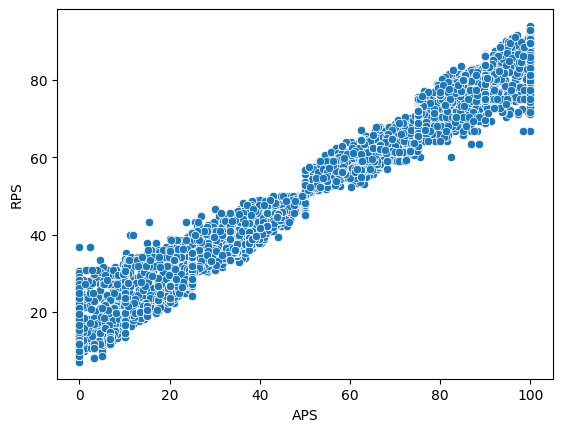

In [5]:
# Sanity Checks: Distribution of APS & RPS

band_check = score_output.copy()

band_check.groupby('APS_band')['APS'].describe()

check_lambda = score_output.copy()
check_lambda['diff'] = check_lambda['RPS'] - check_lambda['raw_rps']

check_lambda[['n_cohort_assessment', 'raw_rps', 'RPS', 'diff']].head(20)

import seaborn as sns

sns.scatterplot(data=score_output, x='APS', y='RPS')

score_output.sample(10)[[
    'category_assessment',
    'score',
    'APS',
    'APS_band',
    'RPS'
]]

In [6]:
# 9. SET UP PLAYER ID FOR ARCHETYPE ANALYSIS

import pandas as pd
import numpy as np

# Use scoring_df, since it already contains the most recent attempt per player-assessment
arch_df = scoring_df.copy()

# Create full name
arch_df['full_name'] = (
    arch_df['first_name'].fillna('').astype(str).str.strip() + ' ' +
    arch_df['last_name'].fillna('').astype(str).str.strip()
).str.strip()

print("Archetype input shape:", arch_df.shape)
print(arch_df.columns.tolist())
arch_df[['full_name', 'cohort', 'category_assessment', 'score', 'APS', 'RPS']].head()


# 10. MAP CATEGORY_ASSESSMENT TO CORE SKILLS

skill_map = {
    # Dribbling
    'Circuit Training Knockout': 'Dribbling',
    'Circuit Training Knockout-Obstacle': 'Dribbling',
    'Fast Feet Architect': 'Dribbling',
    'Fast Feet Maestro': 'Dribbling',
    'Fast Feet Vision': 'Dribbling',
    'ICON 4M Architect': 'Dribbling',
    'ICON 4M Maestro': 'Dribbling',
    'ICON 4M Vision': 'Dribbling',
    'ICON V2 Architect': 'Dribbling',
    'ICON V2 Maestro': 'Dribbling',
    'ICON V2 Vision': 'Dribbling',

    # Passing
    'Circuit Training Pass Find 1': 'Passing',

    # First Touch
    'Tech Touch Ground & Tech Touch Air Receive 10 Air': 'First Touch',
    'Tech Touch Ground & Tech Touch Air Receive 10 Ground': 'First Touch',

    # Vision / cognitive
    'Reflexion Edge Hand Eye Coordination': 'Vision',
    'Reflexion Edge Reaction Time': 'Vision',
    'Reflexion Edge Tracking': 'Vision',
    'Reflexion Edge Inhibition': 'Vision',
    'Reflexion Edge Prioritization': 'Vision',

    # Agility / speed
    'Freelap 10yd Dash': 'Agility',
    'Freelap 20yd Dash': 'Agility',
    'Freelap 10yd Dash Ball': 'Agility',
    'Freelap 20yd Dash Ball': 'Agility',

    # Explosiveness
    'Vertical Jump Vertical': 'Explosiveness'
}

arch_df['skill'] = arch_df['category_assessment'].map(skill_map)

print("Skill counts:")
print(arch_df['skill'].value_counts(dropna=False))

print("\nUnmapped category_assessment values:")
print(sorted(arch_df.loc[arch_df['skill'].isna(), 'category_assessment'].unique()))

# 11. KEEP MAPPED ROWS ONLY

arch_df = arch_df.dropna(subset=['skill']).copy()

print("Mapped archetype dataset shape:", arch_df.shape)
arch_df[['full_name', 'cohort', 'category_assessment', 'skill', 'APS', 'RPS']].head(20)

# 12. USE BOTH APS AND RPS

# Keep both scores
arch_df = arch_df.copy()

# Rename for clarity
arch_df['APS_score'] = arch_df['APS']
arch_df['RPS_score'] = arch_df['RPS']

print("Using BOTH APS and RPS for archetypes")
arch_df[['full_name', 'category_assessment', 'skill', 'APS_score', 'RPS_score']].head(10)

# 13. BUILD PLAYER x SKILL SCORES (APS + RPS)

player_skill_long = (
    arch_df.groupby(['full_name', 'skill'])
           .agg(
               APS_skill_score=('APS_score', 'mean'),
               RPS_skill_score=('RPS_score', 'mean')
           )
           .reset_index()
)

player_skill_long.head(20)

# 14. CREATE TWO SKILL MATRICES (APS + RPS)

player_skill_matrix_APS = player_skill_long.pivot(
    index='full_name',
    columns='skill',
    values='APS_skill_score'
)

player_skill_matrix_APS.head()


player_skill_matrix_RPS = player_skill_long.pivot(
    index='full_name',
    columns='skill',
    values='RPS_skill_score'
)

player_skill_matrix_RPS.head()

# 15. FILTER PLAYERS (BASED ON APS MATRIX)

player_coverage = (
    player_skill_matrix_APS.notna()
                          .sum(axis=1)
                          .reset_index(name='num_skills_present')
                          .sort_values('num_skills_present', ascending=False)
)

min_skills_required = 5

usable_players = player_coverage.loc[
    player_coverage['num_skills_present'] >= min_skills_required,
    'full_name'
]

APS_matrix = player_skill_matrix_APS.loc[usable_players].copy()
RPS_matrix = player_skill_matrix_RPS.loc[usable_players].copy()

print("Usable players:", len(APS_matrix))

# 16. FILL MISSING VALUES (APS + RPS)

#for col in APS_matrix.columns:
    #APS_matrix[col] = APS_matrix[col].fillna(APS_matrix[col].mean())

#for col in RPS_matrix.columns:
   # RPS_matrix[col] = RPS_matrix[col].fillna(RPS_matrix[col].mean())

   # 17. KEEP CORE SKILLS

core_skills = ['Dribbling', 'Passing', 'Vision', 'Agility', 'First Touch']

for skill in core_skills:
    if skill not in APS_matrix.columns:
        APS_matrix[skill] = APS_matrix.mean(axis=1)
    if skill not in RPS_matrix.columns:
        RPS_matrix[skill] = RPS_matrix.mean(axis=1)

APS_core = APS_matrix[core_skills].copy()
RPS_core = RPS_matrix[core_skills].copy()

# 18. ARCHETYPE SCORES (APS + RPS)

def compute_archetypes(df):
    out = df.copy()

    out['Playmaker'] = (
        0.30 * out['Passing'] +
        0.30 * out['Vision'] +
        0.25 * out['First Touch'] +
        0.10 * out['Dribbling'] +
        0.05 * out['Agility']
    )

    out['Explosive Athlete'] = (
        0.40 * out['Agility'] +
        0.35 * out['Dribbling'] +
        0.15 * out['First Touch'] +
        0.10 * out['Vision']
    )

    out['Attacker'] = (
        0.40 * out['Dribbling'] +
        0.30 * out['Agility'] +
        0.20 * out['First Touch'] +
        0.10 * out['Vision']
    )

    out['Control / Possession'] = (
        0.35 * out['First Touch'] +
        0.35 * out['Passing'] +
        0.20 * out['Vision'] +
        0.10 * out['Dribbling']
    )

    out['Balanced'] = out[core_skills].mean(axis=1)

    return out

APS_archetypes = compute_archetypes(APS_core)
RPS_archetypes = compute_archetypes(RPS_core)

# 19. ASSIGN PRIMARY ARCHETYPE (APS + RPS)

archetype_cols = [
    'Playmaker',
    'Explosive Athlete',
    'Attacker',
    'Control / Possession',
    'Balanced'
]

def assign_primary(df):
    df = df.copy()
    df['primary_archetype'] = df[archetype_cols].idxmax(axis=1)
    df['primary_archetype_score'] = df[archetype_cols].max(axis=1)
    return df

APS_archetypes = compute_archetypes(APS_core)
RPS_archetypes = compute_archetypes(RPS_core)

APS_archetypes = assign_primary(APS_archetypes)
RPS_archetypes = assign_primary(RPS_archetypes)

# 20. CLEAN PRESENTATION TABLE

APS_archetypes = APS_archetypes.reset_index().rename(columns={'index': 'full_name'})
RPS_archetypes = RPS_archetypes.reset_index().rename(columns={'index': 'full_name'})

# Keep only skill scores + main archetype
APS_display = APS_archetypes[
    ['full_name'] + core_skills + ['primary_archetype', 'primary_archetype_score']
].rename(columns={
    'Dribbling': 'Dribbling_APS',
    'Passing': 'Passing_APS',
    'Vision': 'Vision_APS',
    'Agility': 'Agility_APS',
    'First Touch': 'First_Touch_APS',
    'primary_archetype': 'primary_archetype_APS',
    'primary_archetype_score': 'primary_archetype_score_APS'
})

RPS_display = RPS_archetypes[
    ['full_name'] + core_skills + ['primary_archetype', 'primary_archetype_score']
].rename(columns={
    'Dribbling': 'Dribbling_RPS',
    'Passing': 'Passing_RPS',
    'Vision': 'Vision_RPS',
    'Agility': 'Agility_RPS',
    'First Touch': 'First_Touch_RPS',
    'primary_archetype': 'primary_archetype_RPS',
    'primary_archetype_score': 'primary_archetype_score_RPS'
})

final_archetype_table = APS_display.merge(
    RPS_display,
    on='full_name',
    how='inner'
)

final_archetype_table = final_archetype_table.round(1)

final_archetype_table.head(20)

# 21.  PLAYER METADATA

player_meta = (
    arch_df.groupby('full_name')
           .agg(
               age_group=('age_group', 'first'),
               gender_clean=('gender_clean', 'first'),
               cohort=('cohort', 'first')
           )
           .reset_index()
)

final_archetype_table = player_meta.merge(
    final_archetype_table,
    on='full_name',
    how='right'
)

final_archetype_table.head(20)

# 22. PRESENTATION TABLE (APS)

presentation_table = final_archetype_table[
    [
        'full_name', 'cohort',
        'Dribbling_APS', 'Passing_APS', 'Vision_APS', 'Agility_APS', 'First_Touch_APS',
        'primary_archetype_APS',

    ]
].sort_values('full_name')

presentation_table.head(20)

# 22. PRESENTATION TABLE (RPS)
presentation_table = final_archetype_table[
    [
        'full_name', 'cohort',

        'Dribbling_RPS', 'Passing_RPS', 'Vision_RPS', 'Agility_RPS', 'First_Touch_RPS',
        'primary_archetype_RPS'
    ]
].sort_values('full_name')

presentation_table.head(20)

Archetype input shape: (7339, 26)
['first_name', 'last_name', 'gender', 'col_d', 'category', 'assessment', 'score', 'timestamp', 'category_assessment', 'age_group', 'gender_clean', 'cohort', 'higher_is_better', 'q10', 'q25', 'q50', 'q75', 'q90', 'n_cohort_assessment', 'APS', 'rank_order_value', 'raw_rps', 'n_group', 'RPS', 'APS_band', 'full_name']
Skill counts:
skill
Dribbling        3390
Vision           1439
First Touch      1005
Agility           763
Passing           480
Explosiveness     262
Name: count, dtype: int64

Unmapped category_assessment values:
[]
Mapped archetype dataset shape: (7339, 27)
Using BOTH APS and RPS for archetypes
Usable players: 227


,full_name,cohort,Dribbling_RPS,Passing_RPS,Vision_RPS,Agility_RPS,First_Touch_RPS,primary_archetype_RPS
146,AJ Bussell,1_M,27.7,13.8,40.5,NaN,40.5,Balanced
2,AJ Cochran,3_M,53.6,60.0,47.1,46.9,47.1,Control / Possession
145,Ace Loureiro,3_M,63.0,67.0,65.3,30.4,71.1,Control / Possession
144,Aidan McCrory,2_M,39.1,80.9,71.6,55.1,23.3,Playmaker
143,Aiden Carmichael,1_M,32.4,61.2,41.8,68.0,47.9,Balanced
12,Alex Dalou,3_M,68.3,80.0,57.5,40.3,69.7,Control / Possession
148,Alex Lee,3_M,37.1,60.0,76.7,54.2,47.3,Playmaker
11,Alex Munn,3_M,42.4,41.0,59.7,73.8,68.0,Explosive Athlete
10,Alexander Dickerson,2_M,71.7,86.7,63.8,53.9,65.8,Control / Possession
9,Alexander Shunk,2_M,67.8,80.9,58.6,35.7,26.9,Playmaker
